<a href="https://colab.research.google.com/github/borhanur-rahman/Dengu_Biomarker_Discovery/blob/main/Compendium_Sample_Specific_Biomarkers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 1 — Load compendium + metadata
Assume you already have:

compendium_ml_raw_counts.csv (genes × samples)
compendium_metadata.csv (rows = samples)

In [ ]:
# ============================================================
# CELL 1: INSTALL REQUIRED PACKAGES
# ============================================================
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn

In [ ]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
# ============================================================
# CELL 3: SET FILE PATHS AND PARAMETERS
# ============================================================

# Input files (update these to your actual paths)
COUNTS_CSV = "/content/drive/MyDrive/compendium_output/compendium_ml_raw_counts.csv"
META_CSV   = "/content/drive/MyDrive/compendium_output/compendium_metadata.csv"

# Output directory
OUT_DIR = "/content/drive/MyDrive/compendium_output"
os.makedirs(OUT_DIR, exist_ok=True)

# Parameters for gene filtering
N_GENES_FOR_GMM = 20000          # subsample genes for GMM fitting (speed)
MIN_HIGH_FRAC_REF = 0.20        # keep gene if "high-mode" in ≥20% of reference samples
MAD_FALLBACK = 1e-8             # floor for MAD when scale is zero

# Parameters for z-score biomarker selection
Z_THR = 2.5                     # absolute z-score threshold (commonly 2.0, 2.5, or 3.0)
TOP_N_PER_SAMPLE = 30           # top N genes per sample by |z|

print(f"Input counts file: {COUNTS_CSV}")
print(f"Input metadata file: {META_CSV}")
print(f"Output directory: {OUT_DIR}")
print(f"\nParameters:")
print(f"  Z-threshold: {Z_THR}")
print(f"  Top genes per sample: {TOP_N_PER_SAMPLE}")
print(f"  Min high-mode fraction in ref: {MIN_HIGH_FRAC_REF}")

Input counts file: /content/drive/MyDrive/compendium_output/compendium_ml_raw_counts.csv
Input metadata file: /content/drive/MyDrive/compendium_output/compendium_metadata.csv
Output directory: /content/drive/MyDrive/compendium_output

Parameters:
  Z-threshold: 2.5
  Top genes per sample: 30
  Min high-mode fraction in ref: 0.2


In [ ]:
# ============================================================
# CELL 4: LOAD EXPRESSION MATRIX AND METADATA
# ============================================================
print("\n" + "=" * 70)
print("STEP 0: LOADING DATA")
print("=" * 70)

# Load raw counts (genes × samples)
print("Loading count matrix...")
counts = pd.read_csv(COUNTS_CSV, index_col=0)
print(f"Count matrix shape: {counts.shape[0]} genes × {counts.shape[1]} samples")

# Load metadata
print("Loading metadata...")
meta = pd.read_csv(META_CSV, index_col=0)
print(f"Metadata shape: {meta.shape[0]} samples × {meta.shape[1]} attributes")

# Ensure count columns match metadata index
missing_in_meta = set(counts.columns) - set(meta.index)
if missing_in_meta:
    print(f"⚠ Warning: {len(missing_in_meta)} count columns not in metadata")
    print(f"  Example: {list(missing_in_meta)[:5]}")
else:
    print("✓ Count columns match metadata index")

# Show available metadata columns
print(f"\nMetadata columns: {list(meta.columns[:15])}")


STEP 0: LOADING DATA
Loading count matrix...
Count matrix shape: 28035 genes × 1020 samples
Loading metadata...
Metadata shape: 1020 samples × 58 attributes
✓ Count columns match metadata index

Metadata columns: ['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'characteristics_ch1_3', 'characteristics_ch1_4', 'characteristics_ch1_5', 'molecule_ch1']


In [ ]:
# ============================================================
# CELL 5: BUILD UNIFIED CONDITION LABELS FROM METADATA
# ============================================================
print("\n" + "=" * 70)
print("STEP 1: BUILDING CONDITION LABELS")
print("=" * 70)

def build_condition(row):
    """Create unified condition label from disease + status fields."""
    disease = str(row.get("disease", "")).strip()

    if disease == "COVID19":
        inf = str(row.get("infection_status", "")).strip().lower()
        if inf == "pos": return "COVID19_Positive"
        if inf == "neg": return "COVID19_Negative"
        return "COVID19_Unknown"

    if disease == "Diabetes":
        ds = str(row.get("diabetes_status", "")).strip()
        if ds == "T2D": return "Diabetes_T2D"
        if ds == "T3cD": return "Diabetes_T3cD"
        if ds == "IGT": return "Prediabetes_IGT"
        if ds == "IFG": return "Prediabetes_IFG"
        if ds == "ND": return "No_Diabetes_Control"
        return "Diabetes_Unknown"

    if disease == "Sepsis":
        st = str(row.get("disease_state", "")).strip().lower()
        if "sepsis" in st: return "Sepsis_Case"
        if "healthy" in st: return "Healthy_Control"
        return "Sepsis_Unknown"

    if disease == "Dengue":
        st = str(row.get("disease_state", "")).strip().lower()
        if "dhf" in st: return "Dengue_DHF"
        if "df" in st or "dengue fever" in st: return "Dengue_DF"
        return "Dengue_Unknown"

    return "Unknown"

# Apply function to create condition column
meta["condition"] = meta.apply(build_condition, axis=1)

# Display distribution of conditions
print("\nCondition distribution:")
cond_dist = meta["condition"].value_counts()
for cond, count in cond_dist.items():
    print(f"  {cond}: {count} samples")

# Check for unknown conditions
if "Unknown" in cond_dist.index and cond_dist["Unknown"] > 0:
    print(f"\n⚠ Warning: {cond_dist['Unknown']} samples have Unknown condition")


STEP 1: BUILDING CONDITION LABELS

Condition distribution:
  COVID19_Positive: 430 samples
  Sepsis_Case: 348 samples
  COVID19_Negative: 54 samples
  Healthy_Control: 44 samples
  Diabetes_T2D: 39 samples
  Prediabetes_IGT: 38 samples
  Diabetes_T3cD: 35 samples
  No_Diabetes_Control: 18 samples
  Dengue_DHF: 6 samples
  Dengue_DF: 5 samples
  Prediabetes_IFG: 3 samples


In [ ]:
# ============================================================
# CELL 6: DEFINE TARGET AND REFERENCE SAMPLE SETS
# ============================================================
print("\n" + "=" * 70)
print("STEP 2: DEFINING TARGET AND REFERENCE SAMPLES")
print("=" * 70)

# Choose target condition (example: Dengue DHF)
target_label = "Dengue_DHF"  # <-- CHANGE THIS to your desired target condition
cond_col = "condition"

print(f"Target condition: {target_label}")

# Create masks
target_mask = meta[cond_col].astype(str).str.strip() == target_label
ref_mask = ~target_mask

# Get sample lists
target_samples = meta.index[target_mask].tolist()
ref_samples = meta.index[ref_mask].tolist()

print(f"\nTarget samples (S_tar): {len(target_samples)}")
print(f"Reference samples (S_ref): {len(ref_samples)}")

# Verify non-empty sets
if len(target_samples) < 2:
    raise ValueError(f"Too few target samples ({len(target_samples)}). Need at least 2.")
if len(ref_samples) < 5:
    raise ValueError(f"Too few reference samples ({len(ref_samples)}). Need at least 5.")

print("✓ Sample sets validated")


STEP 2: DEFINING TARGET AND REFERENCE SAMPLES
Target condition: Dengue_DHF

Target samples (S_tar): 6
Reference samples (S_ref): 1014
✓ Sample sets validated


In [ ]:
# ============================================================
# CELL 7: NORMALIZE EXPRESSION (LOG2 CPM + 1)
# ============================================================
print("\n" + "=" * 70)
print("STEP 3: EXPRESSSION NORMALIZATION")
print("=" * 70)

# Step 3a: Compute library size L_s = Σ_g counts_{g,s}
print("Computing library sizes...")
lib_size = counts.sum(axis=0)
print(f"Library size range: [{lib_size.min():,.0f}, {lib_size.max():,.0f}]")

# Step 3b: Convert to CPM: CPM_{g,s} = (counts_{g,s} / L_s) × 10^6
print("Converting to CPM...")
cpm = counts.div(lib_size, axis=1) * 1e6

# Step 3c: Log transform: X_{g,s} = log2(CPM_{g,s} + 1)
print("Applying log2 transform...")
expr = np.log2(cpm + 1.0)  # genes × samples

print(f"\nExpression matrix after normalization:")
print(f"  Shape: {expr.shape[0]} genes × {expr.shape[1]} samples")
print(f"  Value range: [{expr.min().min():.2f}, {expr.max().max():.2f}]")
print(f"  Mean value: {expr.mean().mean():.2f}")


STEP 3: EXPRESSSION NORMALIZATION
Computing library sizes...
Library size range: [45,683, 34,364,361]
Converting to CPM...
Applying log2 transform...

Expression matrix after normalization:
  Shape: 28035 genes × 1020 samples
  Value range: [0.00, 18.04]
  Mean value: 1.80


In [ ]:
# ============================================================
# CELL 8: COMPUTE ANTIMODE THRESHOLD PER SAMPLE
# ============================================================
print("\n" + "=" * 70)
print("STEP 4: COMPUTING ANTIMODE THRESHOLD PER SAMPLE")
print("=" * 70)

def antimode_threshold_from_gmm(x_1d, random_state=42):
    """
    Fit 2-component GMM to expression vector and compute intersection threshold.
    Implements T_s = antimode(s) from the pipeline documentation.
    """
    x = np.asarray(x_1d, dtype=float)
    x = x[np.isfinite(x)]  # Remove NaN/Inf

    if x.shape[0] < 10:
        return float(np.median(x)) if x.shape[0] > 0 else 0.0

    x = x.reshape(-1, 1)

    # Fit 2-component Gaussian Mixture Model
    gmm = GaussianMixture(n_components=2, random_state=random_state)
    gmm.fit(x)

    weights = gmm.weights_.ravel()
    means = gmm.means_.ravel()
    vars_ = gmm.covariances_.ravel()

    # Order components by mean (low-mode first, high-mode second)
    order = np.argsort(means)
    low_idx, high_idx = order[0], order[1]

    w1, m1, v1 = weights[low_idx], means[low_idx], vars_[low_idx]
    w2, m2, v2 = weights[high_idx], means[high_idx], vars_[high_idx]

    # Solve for intersection of two Gaussians:
    # w1*N(m1,v1) = w2*N(m2,v2) → quadratic equation
    a = (1/(2*v2)) - (1/(2*v1))
    b = (m1/v1) - (m2/v2)
    c = (m2**2/(2*v2)) - (m1**2/(2*v1)) + np.log((w2*np.sqrt(v1)) / (w1*np.sqrt(v2)))

    if abs(a) < 1e-12:
        # Nearly linear, use midpoint
        return float((m1 + m2) / 2.0)

    roots = np.roots([a, b, c])
    roots = np.real(roots[np.isreal(roots)])

    lo, hi = min(m1, m2), max(m1, m2)
    candidates = [r for r in roots if (r >= lo and r <= hi)]

    if not candidates:
        return float((m1 + m2) / 2.0)

    return float(np.median(candidates))


# Compute T_s for each sample
samples_all = expr.columns.tolist()
genes_arr = expr.index.values
rng = np.random.default_rng(42)

print(f"Fitting GMM for {len(samples_all)} samples...")
T_sample = {}  # Dictionary: T_sample[sample_id] = antimode threshold

for i, s in enumerate(samples_all):
    x = expr[s].values  # Expression across all genes for sample s

    # Subsample genes for speed
    if x.shape[0] > N_GENES_FOR_GMM:
        idx = rng.choice(x.shape[0], size=N_GENES_FOR_GMM, replace=False)
        x_sub = x[idx]
    else:
        x_sub = x

    T_sample[s] = antimode_threshold_from_gmm(x_sub, random_state=42)

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(samples_all)} samples")

print(f"\n✓ Computed antimode thresholds for {len(T_sample)} samples")
print(f"Threshold range: [{min(T_sample.values()):.2f}, {max(T_sample.values()):.2f}]")


STEP 4: COMPUTING ANTIMODE THRESHOLD PER SAMPLE
Fitting GMM for 1020 samples...
  Processed 100/1020 samples
  Processed 200/1020 samples
  Processed 300/1020 samples
  Processed 400/1020 samples
  Processed 500/1020 samples
  Processed 600/1020 samples
  Processed 700/1020 samples
  Processed 800/1020 samples
  Processed 900/1020 samples
  Processed 1000/1020 samples

✓ Computed antimode thresholds for 1020 samples
Threshold range: [0.00, 3.63]


In [ ]:
# ============================================================
# CELL 9: AVERAGE ANTIMODE PER CONDITION
# ============================================================
print("\n" + "=" * 70)
print("STEP 5: COMPUTING CONDITION-LEVEL ANTIMODE THRESHOLDS")
print("=" * 70)

# Get condition labels for all samples
cond_series = meta["condition"].astype(str)

# Group samples by condition
conditions = sorted(set(cond_series.loc[samples_all].astype(str).tolist()))

T_condition = {}  # Dictionary: T_condition[condition] = median antimode

for c in conditions:
    # Find all samples with this condition
    sc = [s for s in samples_all if str(cond_series.loc[s]) == c]
    vals = [T_sample[s] for s in sc if s in T_sample]

    if len(vals) > 0:
        # T_c = median({T_s : s ∈ S_c})
        T_condition[c] = float(np.median(vals))

print(f"Computed T_c for {len(T_condition)} conditions:")
for c in sorted(T_condition.keys()):
    n_samples = sum(1 for s in samples_all if str(cond_series.loc[s]) == c)
    print(f"  {c}: T_c = {T_condition[c]:.4f} (from {n_samples} samples)")

# Save for reference
pd.Series(T_condition).to_csv(os.path.join(OUT_DIR, "antimode_thresholds_per_condition.csv"))
print(f"\n✓ Saved antimode thresholds to: {OUT_DIR}/antimode_thresholds_per_condition.csv")


STEP 5: COMPUTING CONDITION-LEVEL ANTIMODE THRESHOLDS
Computed T_c for 11 conditions:
  COVID19_Negative: T_c = 2.2311 (from 54 samples)
  COVID19_Positive: T_c = 2.2371 (from 430 samples)
  Dengue_DF: T_c = 1.7106 (from 5 samples)
  Dengue_DHF: T_c = 1.6989 (from 6 samples)
  Diabetes_T2D: T_c = 1.7128 (from 39 samples)
  Diabetes_T3cD: T_c = 1.6963 (from 35 samples)
  Healthy_Control: T_c = 1.9010 (from 44 samples)
  No_Diabetes_Control: T_c = 1.6592 (from 18 samples)
  Prediabetes_IFG: T_c = 1.6337 (from 3 samples)
  Prediabetes_IGT: T_c = 1.6690 (from 38 samples)
  Sepsis_Case: T_c = 1.8107 (from 348 samples)

✓ Saved antimode thresholds to: /content/drive/MyDrive/compendium_output/antimode_thresholds_per_condition.csv


In [ ]:
# ============================================================
# CELL 10: FILTER LOW-EXPRESSED GENES (DROP, NOT ZERO!)
# ============================================================
print("\n" + "=" * 70)
print("STEP 6: FILTERING LOW-EXPRESSED GENES")
print("=" * 70)

print(f"Filter criteria: High-mode in ≥{MIN_HIGH_FRAC_REF*100:.0f}% of {len(ref_samples)} reference samples")
print(f"Required minimum: ceil({MIN_HIGH_FRAC_REF} × {len(ref_samples)}) = {int(np.ceil(MIN_HIGH_FRAC_REF * len(ref_samples)))} samples")

# Count how many times each gene is "high-mode" in reference samples
gene_high_count = np.zeros(len(genes_arr), dtype=int)

print(f"\nCounting high-mode occurrences across reference samples...")
for i, s in enumerate(ref_samples):
    c = str(cond_series.loc[s])
    if c not in T_condition:
        continue

    thr = T_condition[c]  # Use T_c(s) = T_condition[c]

    # High(g, s) = I[X_{g,s} ≥ T_{c(s)}]
    high_mask = expr[s].values >= thr
    gene_high_count += high_mask.astype(int)

    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(ref_samples)} reference samples")

# Keep genes where freq_ref(g) ≥ α
min_count = int(np.ceil(MIN_HIGH_FRAC_REF * len(ref_samples)))
kept_mask = gene_high_count >= min_count
kept_genes = genes_arr[kept_mask]

print(f"\nGenes kept after filtering: {kept_genes.shape[0]} / {len(genes_arr)} ({100*kept_genes.shape[0]/len(genes_arr):.1f}%)")
print(f"Genes dropped: {len(genes_arr) - kept_genes.shape[0]}")

# Create filtered expression matrix
expr_filt = expr.loc[kept_genes]  # G' × N
print(f"Filtered expression matrix shape: {expr_filt.shape[0]} genes × {expr_filt.shape[1]} samples")

# Save filtered gene list
pd.DataFrame({"gene": kept_genes}).to_csv(os.path.join(OUT_DIR, "filtered_gene_list.csv"), index=False)
print(f"✓ Saved filtered gene list to: {OUT_DIR}/filtered_gene_list.csv")


STEP 6: FILTERING LOW-EXPRESSED GENES
Filter criteria: High-mode in ≥20% of 1014 reference samples
Required minimum: ceil(0.2 × 1014) = 203 samples

Counting high-mode occurrences across reference samples...
  Processed 50/1014 reference samples
  Processed 100/1014 reference samples
  Processed 150/1014 reference samples
  Processed 200/1014 reference samples
  Processed 250/1014 reference samples
  Processed 300/1014 reference samples
  Processed 350/1014 reference samples
  Processed 400/1014 reference samples
  Processed 450/1014 reference samples
  Processed 500/1014 reference samples
  Processed 550/1014 reference samples
  Processed 600/1014 reference samples
  Processed 650/1014 reference samples
  Processed 700/1014 reference samples
  Processed 750/1014 reference samples
  Processed 800/1014 reference samples
  Processed 850/1014 reference samples
  Processed 900/1014 reference samples
  Processed 950/1014 reference samples
  Processed 1000/1014 reference samples

Genes kept

In [ ]:
# ============================================================
# CELL 11: COMPUTE ROBUST Z-SCORES (REFERENCE = NON-TARGET ONLY)
# ============================================================
print("\n" + "=" * 70)
print("STEP 7: COMPUTING ROBUST Z-SCORES")
print("=" * 70)

# Subset expression matrices
ref_expr_f = expr_filt[ref_samples]      # G' × |S_ref|
target_expr_f = expr_filt[target_samples]  # G' × |S_tar|

print(f"Reference expression shape: {ref_expr_f.shape}")
print(f"Target expression shape: {target_expr_f.shape}")

# For each gene g ∈ G', compute μ_g and σ_g from reference only
# μ_g = median({X_{g,s} : s ∈ S_ref})
med = ref_expr_f.median(axis=1)

# MAD_g = median(|X_{g,s} − μ_g| : s ∈ S_ref)
mad = (ref_expr_f.sub(med, axis=0).abs()).median(axis=1)

# σ_g = 1.4826 × MAD_g
scale = (1.4826 * mad).replace(0, MAD_FALLBACK)

print(f"\nReference statistics per gene:")
print(f"  Median range: [{med.min():.2f}, {med.max():.2f}]")
print(f"  Scale range:  [{scale.min():.4f}, {scale.max():.4f}]")

# Compute z-scores: z_{g,s} = (X_{g,s} − μ_g) / σ_g
z = (target_expr_f.sub(med, axis=0)).div(scale, axis=0)  # G' × |S_tar|

# Handle Inf/NaN
z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

print(f"\nZ-score matrix shape: {z.shape[0]} genes × {z.shape[1]} target samples")
print(f"Z-score range: [{z.min().min():.2f}, {z.max().max():.2f}]")
print(f"Mean |z|: {z.abs().mean().mean():.2f}")


STEP 7: COMPUTING ROBUST Z-SCORES
Reference expression shape: (13368, 1014)
Target expression shape: (13368, 6)

Reference statistics per gene:
  Median range: [0.00, 13.34]
  Scale range:  [0.0000, 7.7585]

Z-score matrix shape: 13368 genes × 6 target samples
Z-score range: [-8.77, 1195125161.32]
Mean |z|: 3739842.75


In [ ]:
# ============================================================
# CELL 12: EXTRACT PER-SAMPLE BIOMARKERS FROM Z-SCORES
# ============================================================
print("\n" + "=" * 70)
print("STEP 8: EXTRACTING PER-SAMPLE BIOMARKERS")
print("=" * 70)

per_sample_rows = []

for s in target_samples:
    zs = z[s]  # z-scores for sample s

    # Candidate genes: |z_{g,s}| ≥ z_thr
    cand_mask = zs.abs() >= Z_THR

    if cand_mask.sum() == 0:
        print(f"  {s}: No genes pass |z|≥{Z_THR}")
        continue

    df = pd.DataFrame({
        "sample_id": s,
        "gene": zs.index[cand_mask],
        "z_score": zs[cand_mask].values,
    })

    # Add direction: UP if z > 0, DOWN if z < 0
    df["direction"] = np.where(df["z_score"] > 0, "UP", "DOWN")
    df["abs_z"] = df["z_score"].abs()

    # Rank by |z| and keep top N
    df = df.sort_values("abs_z", ascending=False).head(TOP_N_PER_SAMPLE)
    per_sample_rows.append(df)

# Combine all per-sample results
per_sample_biomarkers = pd.concat(per_sample_rows, ignore_index=True) if per_sample_rows else pd.DataFrame(
    columns=["sample_id", "gene", "z_score", "direction", "abs_z"]
)

print(f"\nTotal per-sample biomarker rows: {per_sample_biomarkers.shape[0]}")
print(f"Number of target samples with biomarkers: {per_sample_biomarkers['sample_id'].nunique()}")

if per_sample_biomarkers.shape[0] > 0:
    print(f"\nBiomarkers per sample:")
    sample_counts = per_sample_biomarkers.groupby("sample_id").size()
    for s, cnt in sample_counts.items():
        print(f"  {s}: {cnt} genes")


STEP 8: EXTRACTING PER-SAMPLE BIOMARKERS

Total per-sample biomarker rows: 180
Number of target samples with biomarkers: 6

Biomarkers per sample:
  GSE215835_GSM6642084: 30 genes
  GSE215835_GSM6642085: 30 genes
  GSE215835_GSM6642086: 30 genes
  GSE215835_GSM6642087: 30 genes
  GSE215835_GSM6642088: 30 genes
  GSE215835_GSM6642089: 30 genes


In [ ]:
# ============================================================
# CELL 13: BUILD UNION PANEL ACROSS TARGET SAMPLES
# ============================================================
print("\n" + "=" * 70)
print("STEP 9: BUILDING UNION PANEL ACROSS TARGET SAMPLES")
print("=" * 70)

if per_sample_biomarkers.shape[0] == 0:
    print("⚠ No biomarkers found. Skipping union panel.")
    panel = pd.DataFrame(columns=["gene", "freq_in_target", "major_direction"])
else:
    # Union: L_union = ∪_i L_{s_i}
    # Frequency: freq_tar(g) = |{i : g ∈ L_{s_i}}|
    freq = per_sample_biomarkers.groupby("gene")["sample_id"].nunique().rename("freq_in_target").reset_index()

    # Direction vote: most common direction across samples
    dir_counts = per_sample_biomarkers.groupby(["gene", "direction"])["sample_id"].nunique().unstack(fill_value=0)
    dir_vote = dir_counts.idxmax(axis=1).reset_index(name="major_direction")
    dir_vote.columns = ["gene", "major_direction"]

    # Merge frequency and direction
    panel = freq.merge(dir_vote, on="gene", how="left")
    panel = panel.sort_values("freq_in_target", ascending=False)

    print(f"\nUnion panel size: {panel.shape[0]} unique genes")
    print(f"\nTop 20 genes in union panel:")
    display(panel.head(20))

    # Frequency distribution
    print(f"\nFrequency distribution:")
    freq_dist = panel["freq_in_target"].value_counts().sort_index()
    for f, cnt in freq_dist.items():
        print(f"  Appears in {f}/{len(target_samples)} samples: {cnt} genes")


STEP 9: BUILDING UNION PANEL ACROSS TARGET SAMPLES

Union panel size: 41 unique genes

Top 20 genes in union panel:


,gene,freq_in_target,major_direction
7,IGHGP,6,UP
8,IGHV1-18,6,UP
19,IGKV3-11,6,UP
23,IGLV1-47,6,UP
22,IGLV1-44,6,UP
14,IGHV3-48,6,UP
15,IGHV3-7,6,UP
11,IGHV3-23,6,UP
10,IGHV3-21,6,UP
40,RPL23AP42,6,UP



Frequency distribution:
  Appears in 1/6 samples: 7 genes
  Appears in 2/6 samples: 4 genes
  Appears in 3/6 samples: 1 genes
  Appears in 4/6 samples: 3 genes
  Appears in 5/6 samples: 6 genes
  Appears in 6/6 samples: 20 genes



STEP 10: VISUALIZING TOP BIOMARKERS


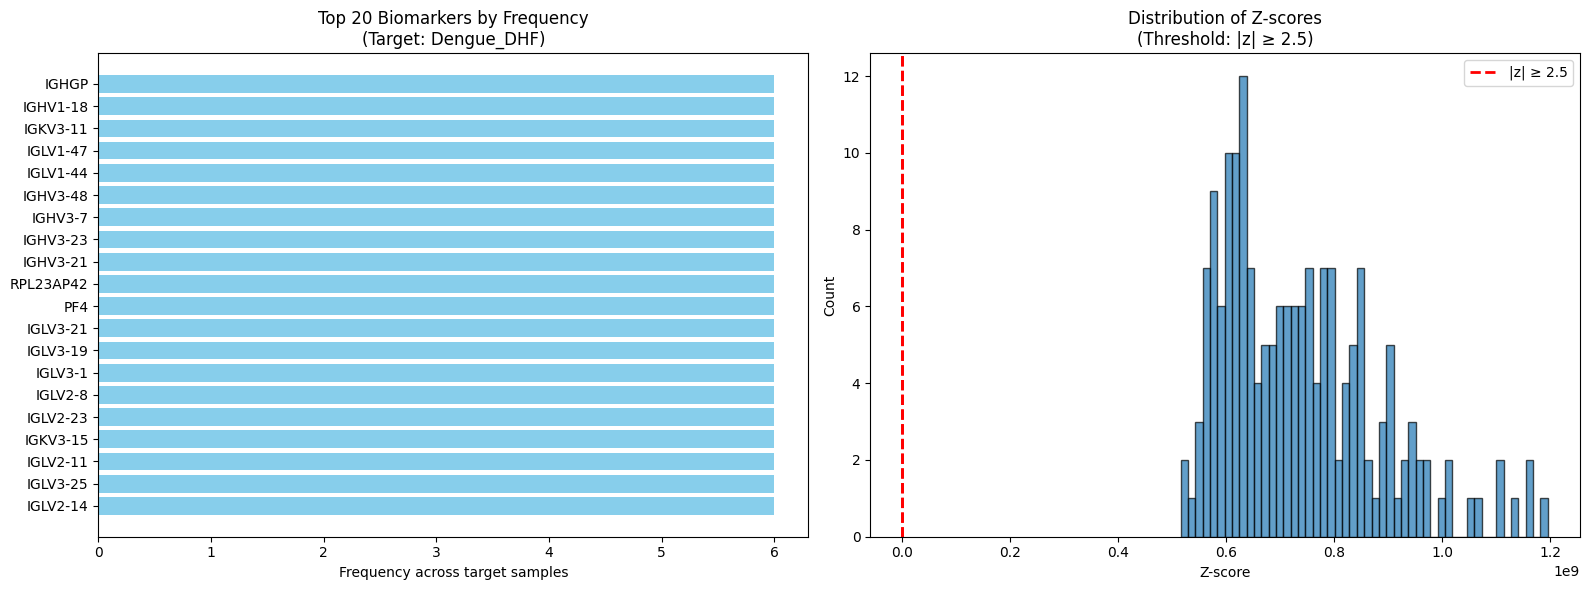

In [ ]:
# ============================================================
# CELL 14: VISUALIZE TOP BIOMARKERS
# ============================================================
print("\n" + "=" * 70)
print("STEP 10: VISUALIZING TOP BIOMARKERS")
print("=" * 70)

if panel.shape[0] == 0:
    print("⚠ No panel to visualize")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar plot: top genes by frequency
    top_freq = panel.head(20)
    ax1 = axes[0]
    ax1.barh(range(len(top_freq)), top_freq["freq_in_target"], color='skyblue')
    ax1.set_yticks(range(len(top_freq)))
    ax1.set_yticklabels(top_freq["gene"].tolist())
    ax1.set_xlabel("Frequency across target samples")
    ax1.set_title(f"Top 20 Biomarkers by Frequency\n(Target: {target_label})")
    ax1.invert_yaxis()
    plt.tight_layout()

    # Distribution of z-scores for top genes
    ax2 = axes[1]
    if per_sample_biomarkers.shape[0] > 0:
        all_z = per_sample_biomarkers["z_score"].values
        ax2.hist(all_z, bins=50, alpha=0.7, edgecolor='black')
        ax2.axvline(Z_THR, color='red', linestyle='--', linewidth=2, label=f'|z| ≥ {Z_THR}')
        ax2.axvline(-Z_THR, color='red', linestyle='--', linewidth=2)
        ax2.set_xlabel("Z-score")
        ax2.set_ylabel("Count")
        ax2.set_title(f"Distribution of Z-scores\n(Threshold: |z| ≥ {Z_THR})")
        ax2.legend()
        plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, "biomarker_visualization.png"), dpi=300)
    plt.show()

In [ ]:
# ============================================================
# CELL 15: SAVE ALL OUTPUTS
# ============================================================
print("\n" + "=" * 70)
print("STEP 11: SAVING OUTPUT FILES")
print("=" * 70)

# Create safe filename
target_safe = target_label.replace(" ", "_").replace("/", "_").replace("(DHF)", "").replace("(DF)", "")

# 1. Per-sample biomarkers
per_sample_path = os.path.join(OUT_DIR, f"{target_safe}_per_sample_biomarkers.csv")
per_sample_biomarkers.to_csv(per_sample_path, index=False)
print(f"✓ Per-sample biomarkers saved to: {per_sample_path}")

# 2. Union panel
panel_path = os.path.join(OUT_DIR, f"{target_safe}_union_panel.csv")
panel.to_csv(panel_path, index=False)
print(f"✓ Union panel saved to: {panel_path}")

# 3. Z-scores (can be large)
z_path = os.path.join(OUT_DIR, f"{target_safe}_z_scores.csv")
z.to_csv(z_path)
print(f"✓ Z-scores saved to: {z_path}")

# 4. Summary statistics
summary_lines = [
    f"PIPELINE: Sample-Specific Biomarker Discovery",
    f"TARGET CONDITION: {target_label}",
    f"--------------------------------------------------------",
    f"Target samples (S_tar): {len(target_samples)}",
    f"Reference samples (S_ref): {len(ref_samples)}",
    f"Original genes (G): {len(genes_arr)}",
    f"Filtered genes (G'): {kept_genes.shape[0]}",
    f"Gene filtering rate: {100*kept_genes.shape[0]/len(genes_arr):.1f}%",
    f"--------------------------------------------------------",
    f"Z-score threshold (z_thr): {Z_THR}",
    f"Top genes per sample (N): {TOP_N_PER_SAMPLE}",
    f"Min high-mode fraction (α): {MIN_HIGH_FRAC_REF}",
    f"--------------------------------------------------------",
    f"Per-sample biomarker rows: {per_sample_biomarkers.shape[0]}",
    f"Samples with biomarkers: {per_sample_biomarkers['sample_id'].nunique()}",
    f"Union panel size: {panel.shape[0]}",
    f"--------------------------------------------------------",
    f"Output files:",
    f"  - {target_safe}_per_sample_biomarkers.csv",
    f"  - {target_safe}_union_panel.csv",
    f"  - {target_safe}_z_scores.csv",
    f"  - filtered_gene_list.csv",
    f"  - antimode_thresholds_per_condition.csv",
    f"  - biomarker_visualization.png",
]

with open(os.path.join(OUT_DIR, f"{target_safe}_pipeline_summary.txt"), "w") as f:
    f.write("\n".join(summary_lines))

print(f"✓ Summary saved to: {OUT_DIR}/{target_safe}_pipeline_summary.txt")

# Final summary
print(f"\n{'='*70}")
print(f"PIPELINE COMPLETE ✅")
print(f"{'='*70}")
print(f"\nAll outputs saved to: {OUT_DIR}")
print(f"\nKey results:")
print(f"  Target samples analyzed: {len(target_samples)}")
print(f"  Reference samples used: {len(ref_samples)}")
print(f"  Genes after filtering: {kept_genes.shape[0]}")
print(f"  Total biomarker rows: {per_sample_biomarkers.shape[0]}")
print(f"  Unique genes in union panel: {panel.shape[0]}")
print(f"{'='*70}")


STEP 11: SAVING OUTPUT FILES
✓ Per-sample biomarkers saved to: /content/drive/MyDrive/compendium_output/Dengue_DHF_per_sample_biomarkers.csv
✓ Union panel saved to: /content/drive/MyDrive/compendium_output/Dengue_DHF_union_panel.csv
✓ Z-scores saved to: /content/drive/MyDrive/compendium_output/Dengue_DHF_z_scores.csv
✓ Summary saved to: /content/drive/MyDrive/compendium_output/Dengue_DHF_pipeline_summary.txt

PIPELINE COMPLETE ✅

All outputs saved to: /content/drive/MyDrive/compendium_output

Key results:
  Target samples analyzed: 6
  Reference samples used: 1014
  Genes after filtering: 13368
  Total biomarker rows: 180
  Unique genes in union panel: 41
